<a href="https://colab.research.google.com/github/Siddwayy/data-visualization-projects/blob/main/Assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

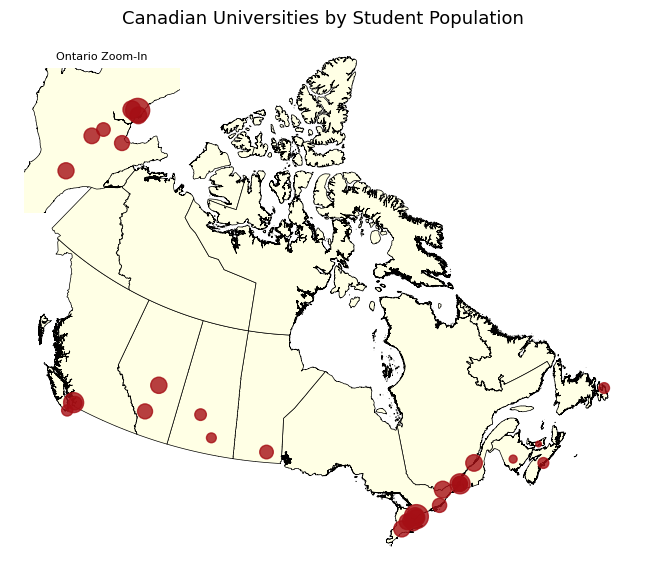

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

canada = gpd.read_file('canada.shp')
unis = gpd.read_file('universities.geojson')

unis = unis.to_crs(canada.crs)

ontario_names = [
    'University of Toronto',
    'Toronto Metropolitan University',
    'York University',
    'University of Waterloo',
    'University of Guelph',
    'McMaster University',
    'University of Western Ontario',
]
ontario_unis = unis[unis['Institution'].isin(ontario_names)]

ont_bounds = ontario_unis.total_bounds
pad = 80000
ont_xlim = (ont_bounds[0] - pad, ont_bounds[2] + pad)
ont_ylim = (ont_bounds[1] - pad, ont_bounds[3] + pad)

scale_factor = 0.003
sizes = unis['Total students'] * scale_factor

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

canada.plot(ax=ax, color='#FFFFE5', edgecolor='black', linewidth=0.5)
unis.plot(ax=ax, color='#A50F15', markersize=sizes, edgecolor='#A50F15', alpha=0.8)

ax.set_title('Canadian Universities by Student Population', fontsize=13)
ax.set_axis_off()

ax_inset = inset_axes(ax, width="25%", height="35%", loc='upper left', borderpad=1)

canada.plot(ax=ax_inset, color='#FFFFE5', edgecolor='black', linewidth=0.5)
ont_sizes = ontario_unis['Total students'] * scale_factor
ontario_unis.plot(ax=ax_inset, color='#A50F15', markersize=ont_sizes, edgecolor='#A50F15', alpha=0.8)

ax_inset.set_xlim(ont_xlim)
ax_inset.set_ylim(ont_ylim)
ax_inset.set_title('Ontario Zoom-In', fontsize=8)
ax_inset.set_axis_off()

for spine in ax_inset.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(0.8)

plt.show()

#Q2#

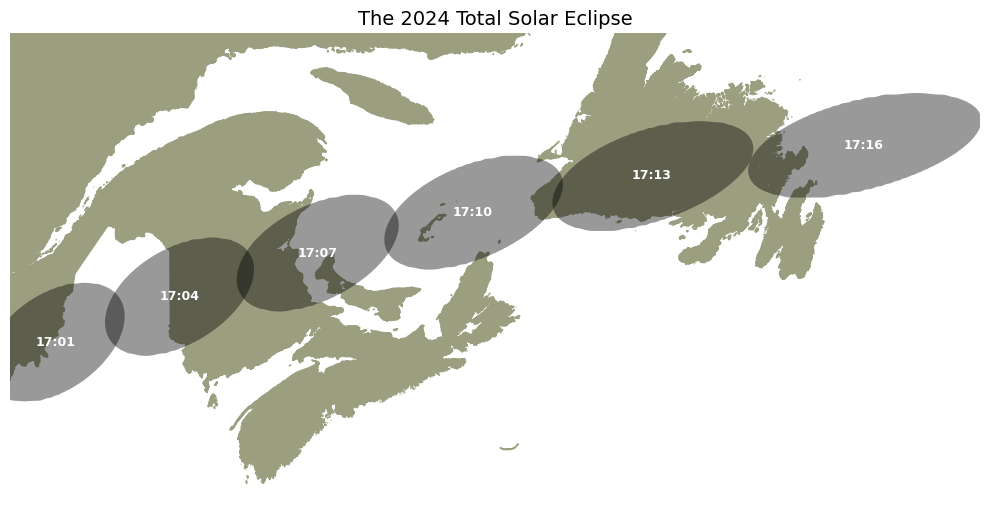

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt

umbra = gpd.read_file('umbra_lo.shp')
canada = gpd.read_file('canada.shp')

canada = canada.to_crs(umbra.crs)

shadow_utc_times = ['19:31:00', '19:34:00', '19:37:00', '19:40:00', '19:43:00', '19:46:00']
shadows = umbra[umbra['UTCTime'].isin(shadow_utc_times)].copy()

ndt_labels = ['17:01', '17:04', '17:07', '17:10', '17:13', '17:16']
utc_to_ndt = dict(zip(shadow_utc_times, ndt_labels))
shadows['NDT'] = shadows['UTCTime'].map(utc_to_ndt)

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

canada.plot(ax=ax, color='#9B9E7F', edgecolor='#9B9E7F')

shadows.plot(ax=ax, color='black', alpha=0.4, edgecolor='none')

for _, row in shadows.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['NDT'], xy=(centroid.x, centroid.y),
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_xlim(-71.5, -49)
ax.set_ylim(43, 50.5)
ax.set_title('The 2024 Total Solar Eclipse', fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [9]:
import geopandas as gpd
import folium
import json

umbra = gpd.read_file('umbra_lo.shp')

shadow_utc_times = ['19:31:00', '19:34:00', '19:37:00', '19:40:00', '19:43:00', '19:46:00']
shadows = umbra[umbra['UTCTime'].isin(shadow_utc_times)].copy()

center_lat = shadows['CenterLat'].mean()
center_lon = shadows['CenterLon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6,
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ, TomTom, Intermap, iPC, USGS, FAO, NPS, NRCAN, GeoBase, Kadaster NL, Ordnance Survey, Esri Japan, METI, Esri China (Hong Kong), and the GIS User Community'
)

geojson_data = json.loads(shadows.to_json())

folium.GeoJson(
    geojson_data,
    style_function=lambda feature: {
        'fillColor': 'grey',
        'color': 'grey',
        'weight': 1,
        'fillOpacity': 0.5,
    }
).add_to(m)

m